# 环境导入

In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from IPython.display import display, HTML

# 中文字体设置
plt.rcParams['axes.unicode_minus'] = False
for font_name in ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']:
    try:
        fm.findfont(font_name, fallback_to_default=False)
        plt.rcParams['font.sans-serif'] = [font_name]
        break
    except:
        continue
%matplotlib inline

# 数据加载与预处理

将原始数据拆分为 10 月（用于建模/EDA）和 11 月（用于验证）

In [2]:
df_raw = pd.read_csv('./my_cohort_data_Oct_Nov.csv')
df_raw['event_time'] = pd.to_datetime(df_raw['event_time'])

# 拆分为 10 月（建模/EDA）和 11 月（验证）
df_oct_raw = df_raw[df_raw['event_time'].dt.month == 10].copy()
df_nov = df_raw[df_raw['event_time'].dt.month == 11].copy()

print(f"10月原始事件数: {len(df_oct_raw):,} 条")
print(f"11月原始事件数: {len(df_nov):,} 条")

# ── 估算浏览时长 ──
max_date = df_oct_raw['event_time'].max()

df_oct_raw = df_oct_raw.sort_values(['user_id', 'event_time'])
df_oct_raw['prev_time'] = df_oct_raw.groupby('user_id')['event_time'].shift(1)
df_oct_raw['time_diff'] = (df_oct_raw['event_time'] - df_oct_raw['prev_time']).dt.total_seconds()
df_oct_raw['active_duration'] = df_oct_raw['time_diff'].apply(
    lambda x: x if pd.notna(x) and x < 1800 else 0
)

user_duration = df_oct_raw.groupby('user_id')['active_duration'].sum().reset_index()
user_duration.columns = ['user_id', 'Estimated_Time']

# ── 聚合 RFM 与浏览行为 ──
purchase_df = df_oct_raw[df_oct_raw['event_type'] == 'purchase']
view_df = df_oct_raw[df_oct_raw['event_type'] == 'view']

rfm = purchase_df.groupby('user_id').agg(
    Last_Purchase=('event_time', 'max'),
    Purchase_Frequency=('event_type', 'count'),
    Total_Spending=('price', 'sum')
).reset_index()
rfm['Recency_Days'] = (max_date - rfm['Last_Purchase']).dt.days

views = view_df.groupby('user_id').agg(
    Pages_Viewed=('event_type', 'count')
).reset_index()

# ── 拼接用户级特征表 ──
df = pd.DataFrame({'user_id': df_oct_raw['user_id'].unique()})
df = df.merge(user_duration, on='user_id', how='left')
df = df.merge(rfm, on='user_id', how='left')
df = df.merge(views, on='user_id', how='left')

df['Purchase_Frequency'] = df['Purchase_Frequency'].fillna(0).astype(int)
df['Total_Spending'] = df['Total_Spending'].fillna(0)
df['Pages_Viewed'] = df['Pages_Viewed'].fillna(0).astype(int)
df['Estimated_Time'] = df['Estimated_Time'].fillna(0)

max_recency = (max_date - df_oct_raw['event_time'].min()).days + 30
df['Recency_Days'] = df['Recency_Days'].fillna(max_recency).astype(int)
# 丢弃中间计算列，保持表格整洁
df.drop(columns=['Last_Purchase'], inplace=True, errors='ignore')

print(f"\n用户级特征表: {df.shape[0]} 用户 × {df.shape[1]} 特征")
print(f"10月用于 EDA + 建模, 11月({df_nov['user_id'].nunique()} 活跃用户)用于验证")
df.head()

10月原始事件数: 308,850 条
11月原始事件数: 259,377 条

用户级特征表: 10000 用户 × 7 特征
10月用于 EDA + 建模, 11月(5524 活跃用户)用于验证


,user_id,Estimated_Time,Last_Purchase,Purchase_Frequency,Total_Spending,Recency_Days,Pages_Viewed
0,296465302,940.0,NaT,0,0.0,60,24
1,351866718,0.0,NaT,0,0.0,60,1
2,369288911,878.0,NaT,0,0.0,60,18
3,370331084,0.0,NaT,0,0.0,60,1
4,386908545,28157.0,NaT,0,0.0,60,270


# EDA探索性数据分析

In [14]:
target_numeric = ['Recency_Days', 'Purchase_Frequency', 'Total_Spending',
                  'Pages_Viewed', 'Estimated_Time']

print(f"数据规模: {df.shape[0]} 行 × {df.shape[1]} 列\n")

miss = df.isnull().sum().sum()
print(f"缺失值: {'✅ 无缺失' if miss == 0 else f'⚠️ {miss} 个'}\n")

summary = df[target_numeric].describe().T.round(2)
summary['skew'] = df[target_numeric].skew().round(2)
display(summary)

print("\n💡 Total_Spending 和 Purchase_Frequency 偏度 > 15，呈长尾右偏。")
print("💡 后续分层采用动态阈值，避免固定分箱被长尾分布扭曲。")

数据规模: 10000 行 × 16 列

缺失值: ⚠️ 8018 个



,count,mean,std,min,25%,50%,75%,max,skew
Recency_Days,10000.0,51.61,17.45,0.0,60.0,60.0,60.00,60.00,-1.76
Purchase_Frequency,10000.0,0.62,3.08,0.0,0.0,0.0,0.00,121.00,16.68
Total_Spending,10000.0,204.28,1640.44,0.0,0.0,0.0,0.00,80724.36,27.81
Pages_Viewed,10000.0,29.63,54.95,0.0,3.0,11.0,32.00,1237.00,5.51
Estimated_Time,10000.0,2000.86,3977.52,0.0,84.0,578.5,2187.25,68989.00,5.42



💡 Total_Spending 和 Purchase_Frequency 偏度 > 15，呈长尾右偏。
💡 后续分层采用动态阈值，避免固定分箱被长尾分布扭曲。


## 单变量分布分析

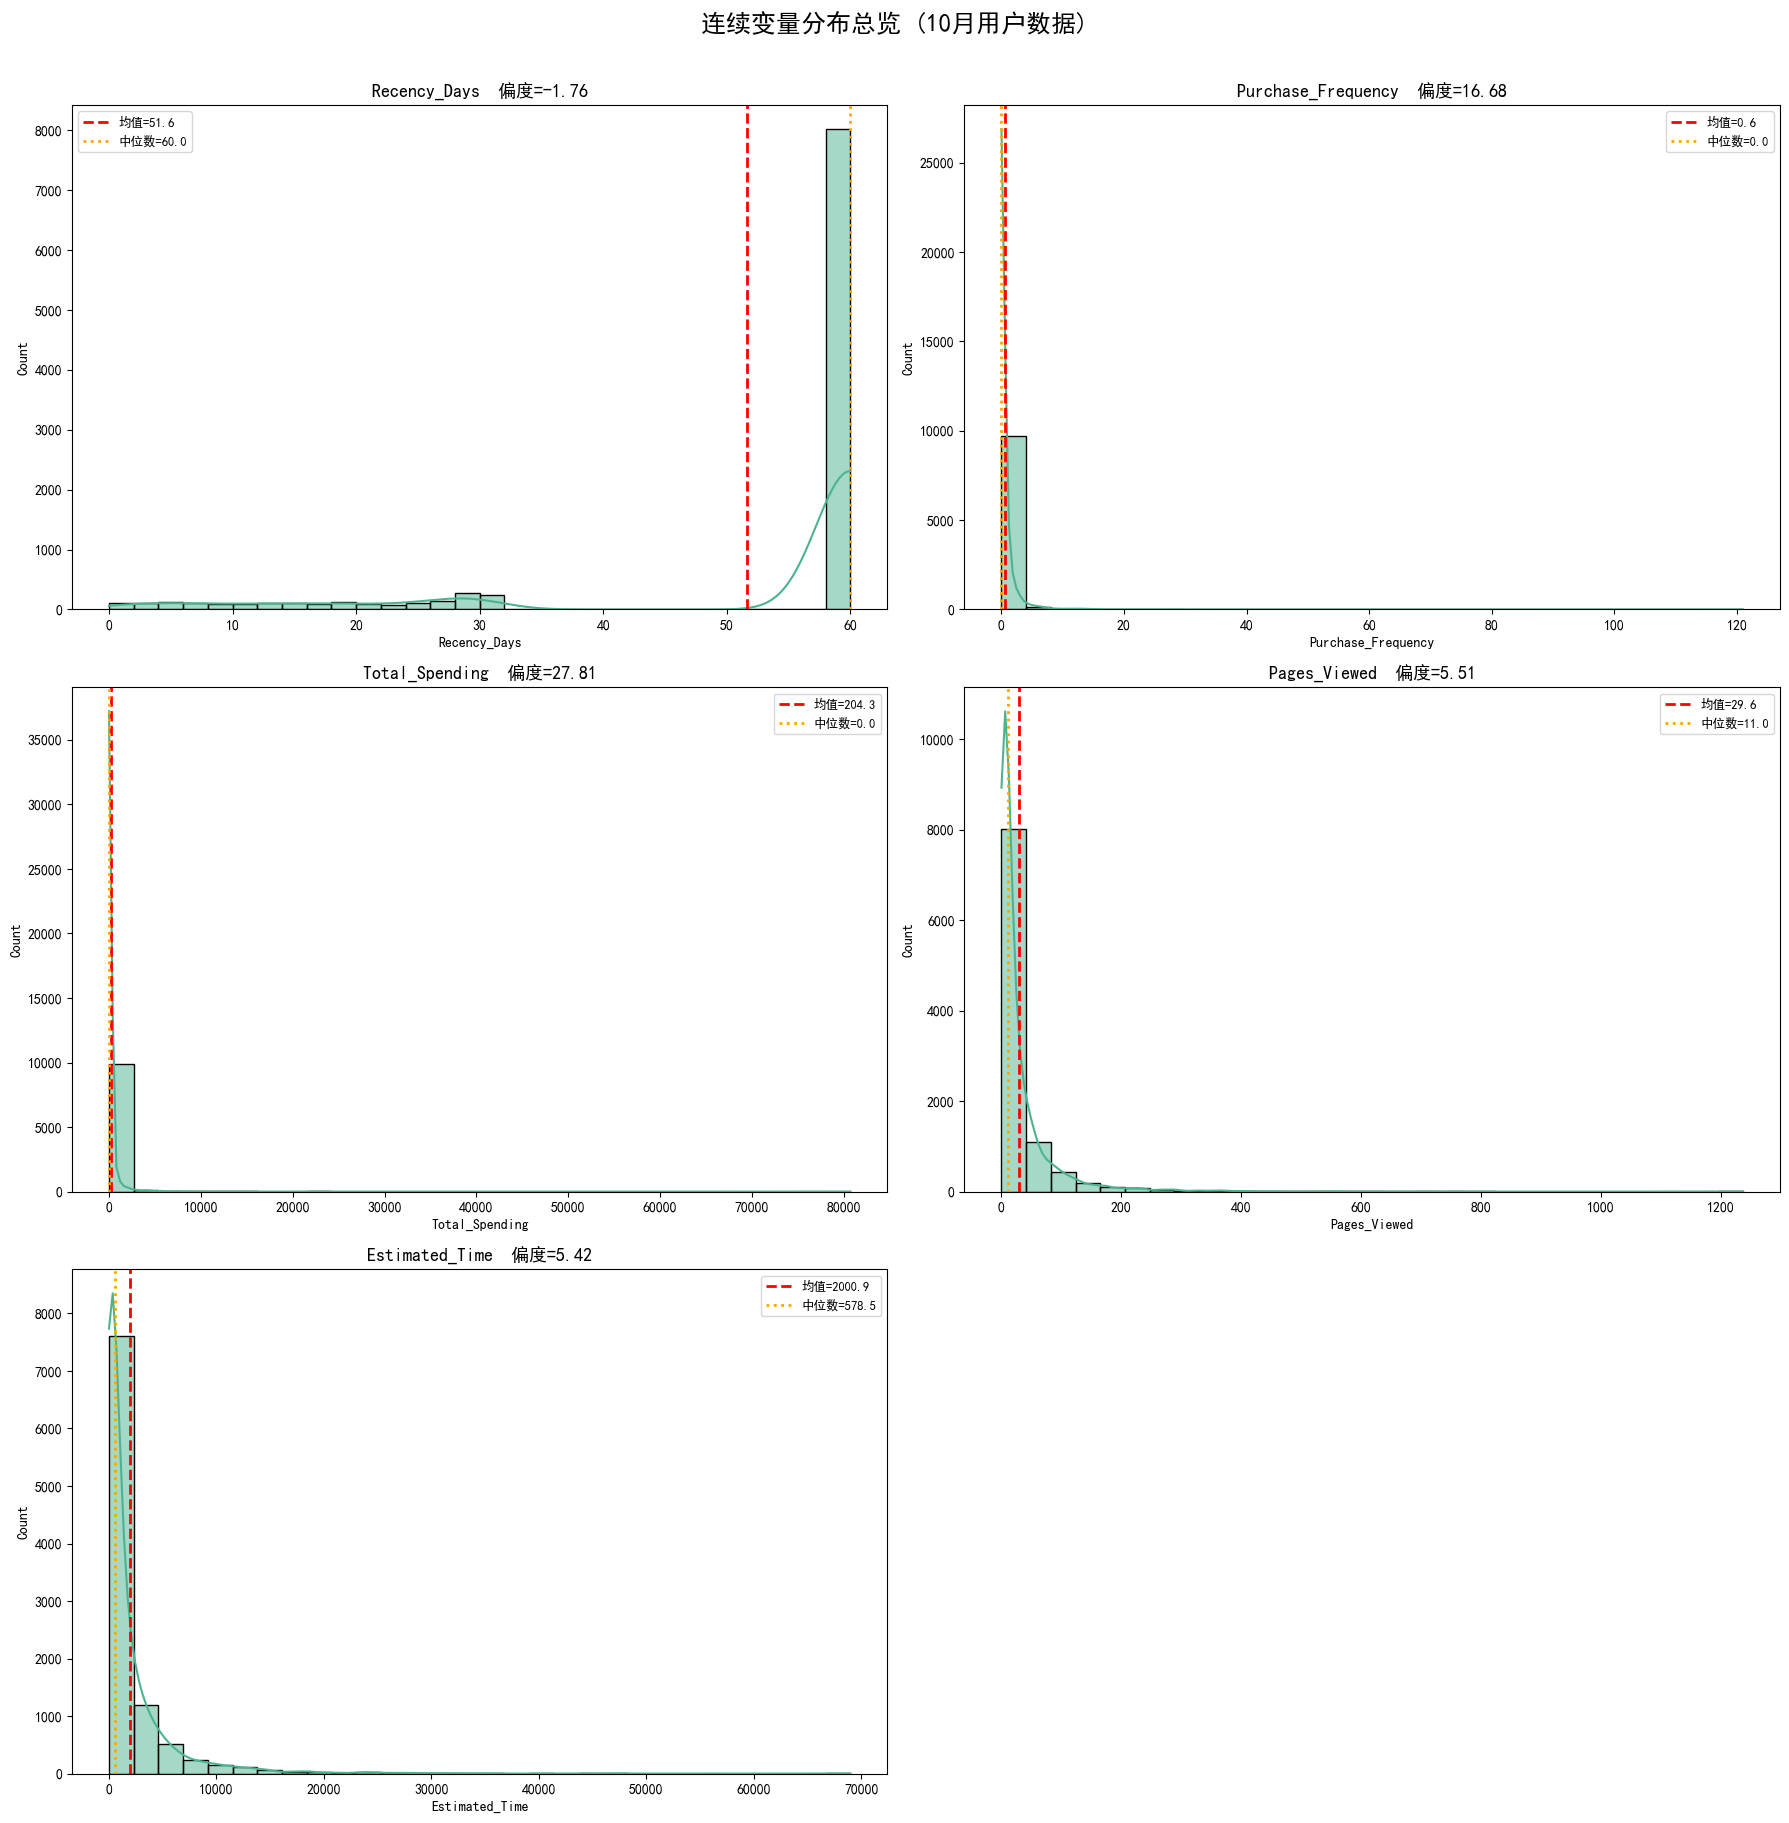

In [4]:
fig, axes = plt.subplots(3, 2, figsize=(18, 18))
for ax, col in zip(axes.flatten(), target_numeric):
    sns.histplot(df[col], kde=True, bins=30, ax=ax, color='#4CB391')
    ax.axvline(df[col].mean(), color='red', ls='--', lw=2, label=f"均值={df[col].mean():.1f}")
    ax.axvline(df[col].median(), color='orange', ls=':', lw=2, label=f"中位数={df[col].median():.1f}")
    ax.set_title(f'{col}  偏度={df[col].skew():.2f}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
axes.flatten()[-1].axis('off')
plt.suptitle('连续变量分布总览 (10月用户数据)', fontsize=18, y=1.01)
plt.tight_layout()
plt.show()

## 多变量相关分析

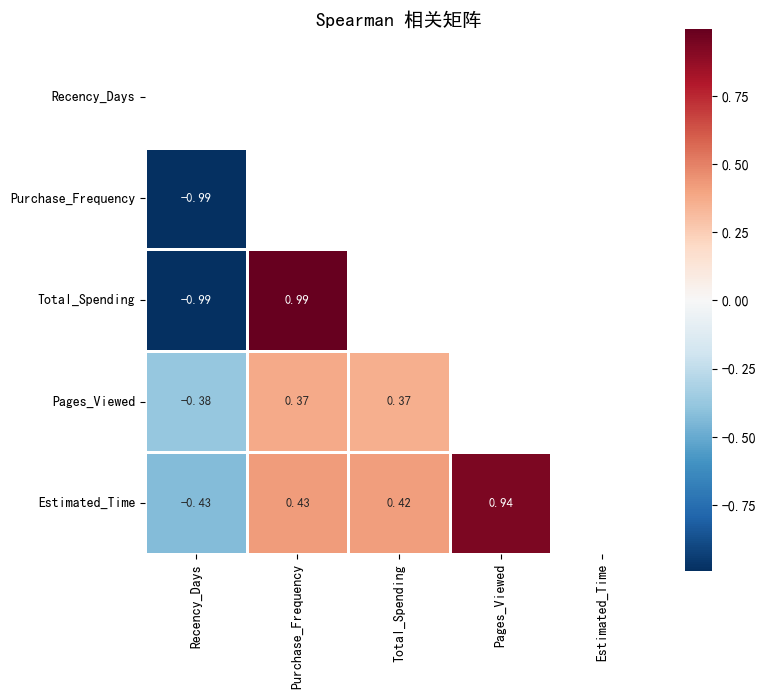

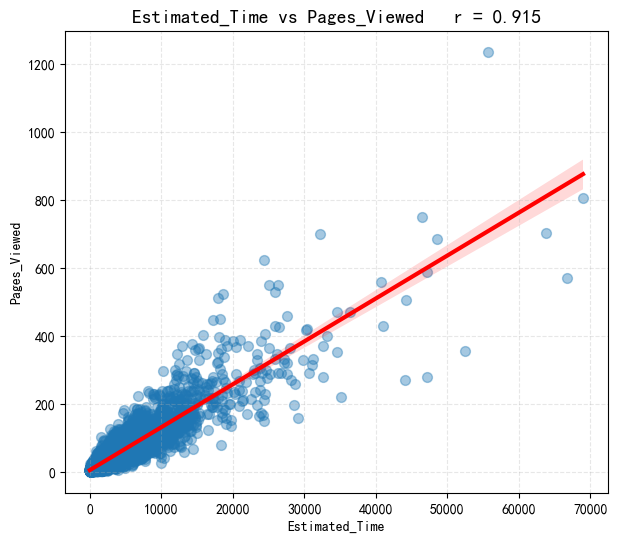

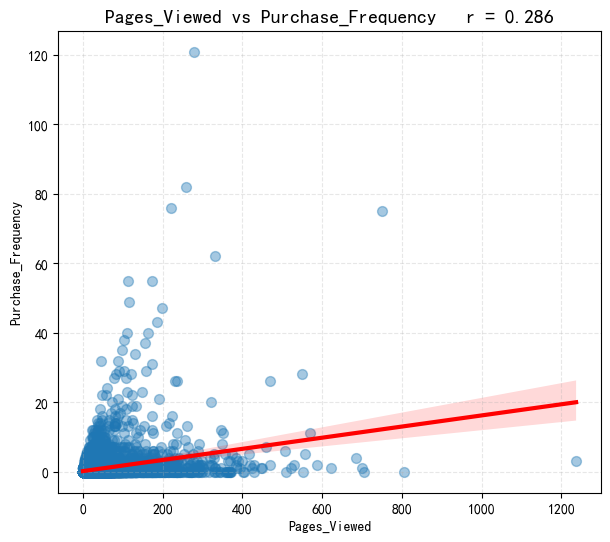

In [16]:
# 3a. 相关性热力图
plt.figure(figsize=(8, 7))
corr = df[target_numeric].corr(method='spearman')
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.8, annot_kws={'fontsize': 9})
plt.title('Spearman 相关矩阵', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# 3b. 估算时长 vs 浏览页数 → 论证 E_Score
r1 = df['Estimated_Time'].corr(df['Pages_Viewed'])
plt.figure(figsize=(7, 6))
sns.regplot(x='Estimated_Time', y='Pages_Viewed', data=df,
            scatter_kws={'alpha': 0.4, 's': 50}, line_kws={'color': 'red', 'lw': 3})
plt.title(f'Estimated_Time vs Pages_Viewed   r = {r1:.3f}', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()


# 3c. 浏览页数 vs 购买频次 → 论证 Friction
r2 = df['Pages_Viewed'].corr(df['Purchase_Frequency'])
plt.figure(figsize=(7, 6))
sns.regplot(x='Pages_Viewed', y='Purchase_Frequency', data=df,
            scatter_kws={'alpha': 0.4, 's': 50}, line_kws={'color': 'red', 'lw': 3})
plt.title(f'Pages_Viewed vs Purchase_Frequency   r = {r2:.3f}', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()


# 定义指标

基于 EDA 发现，构建两个新复合指标：

1. **探索度 E_Score** — 停留时长与浏览页数的加权和
2. **摩擦力 Friction** — 用户平均每完成一次购买需要浏览的页面数

In [7]:
from shared_utils import compute_engagement_metrics

compute_engagement_metrics(
    df,
    pages_col='Pages_Viewed',
    time_col='Estimated_Time',
    freq_col='Purchase_Frequency'
)

df[['user_id','E_Score','Friction']].head()

,user_id,E_Score,Friction
0,296465302,0.475729,24.0
1,351866718,-1.692527,1.0
2,369288911,0.358243,18.0
3,370331084,-1.692527,1.0
4,386908545,1.986520,270.0


# 构建传统RFM模型

In [8]:
from shared_utils import compute_rfm_scores

compute_rfm_scores(
    df,
    r_raw_col='Recency_Days',
    f_raw_col='Purchase_Frequency',
    m_raw_col='Total_Spending'
)

df[['user_id','R_Score','F_Score','M_Score','E_Score','Friction']].head()

,user_id,R_Score,F_Score,M_Score,E_Score,Friction
0,296465302,-0.414667,-0.421975,-0.476614,0.475729,24.0
1,351866718,-0.414667,-0.421975,-0.476614,-1.692527,1.0
2,369288911,-0.414667,-0.421975,-0.476614,0.358243,18.0
3,370331084,-0.414667,-0.421975,-0.476614,-1.692527,1.0
4,386908545,-0.414667,-0.421975,-0.476614,1.986520,270.0


# 精细化用户分层

In [9]:
from shared_utils import classify_users_rfm_3d

final_df, stats = classify_users_rfm_3d(df)


=== RFM 3D 聚类 (n_clusters=8) ===
Silhouette 诊断 (寻找最优 k):
  k=3: silhouette=0.8936
  k=4: silhouette=0.8915
  k=5: silhouette=0.8829
  k=6: silhouette=0.8764
  k=7: silhouette=0.8752
  k=8: silhouette=0.8745 ← 当前选择
  k=9: silhouette=0.8639
  k=10: silhouette=0.8644

簇形心 → RFM 标签映射:
  簇0: R=-0.415  F=-0.422  M=-0.477  (↓↓↓) → 低价值用户
  簇1: R=+2.320  F=+1.116  M=+1.622  (↑↑↑) → 重要价值用户
  簇2: R=+3.998  F=+5.554  M=+3.235  (↑↑↑) → 重要发展用户
  簇3: R=+1.150  F=+1.982  M=+2.168  (↑↑↑) → 一般发展用户
  簇4: R=+0.816  F=+0.943  M=+1.591  (↑↑↑) → 一般保持用户
  簇5: R=+4.448  F=+1.481  M=+1.862  (↑↑↑) → 一般价值用户
  簇6: R=+3.274  F=+2.860  M=+2.453  (↑↑↑) → 重要保持用户
  簇7: R=+1.503  F=+3.613  M=+2.698  (↑↑↑) → 重要挽留用户

=== 逐簇 GMM 阈值 (E_Score / Friction) ===
  簇0 (低价值用户, 8018人):
  silhouette=0.509 | 两簇σ均值=  σ=(0.001, 0.753) | 阈值=-0.809 | 低于阈值=25%
  silhouette=0.675 | 两簇σ均值=  σ=(5.972, 58.666) | 阈值=32.563 | 低于阈值=82%
  簇1 (重要价值用户, 306人):
  silhouette=0.540 | 两簇σ均值=  σ=(0.428, 0.449) | 阈值=0.874 | 低于阈值=45%
  silhouette=0.640 | 

# 用户分层结果可视化

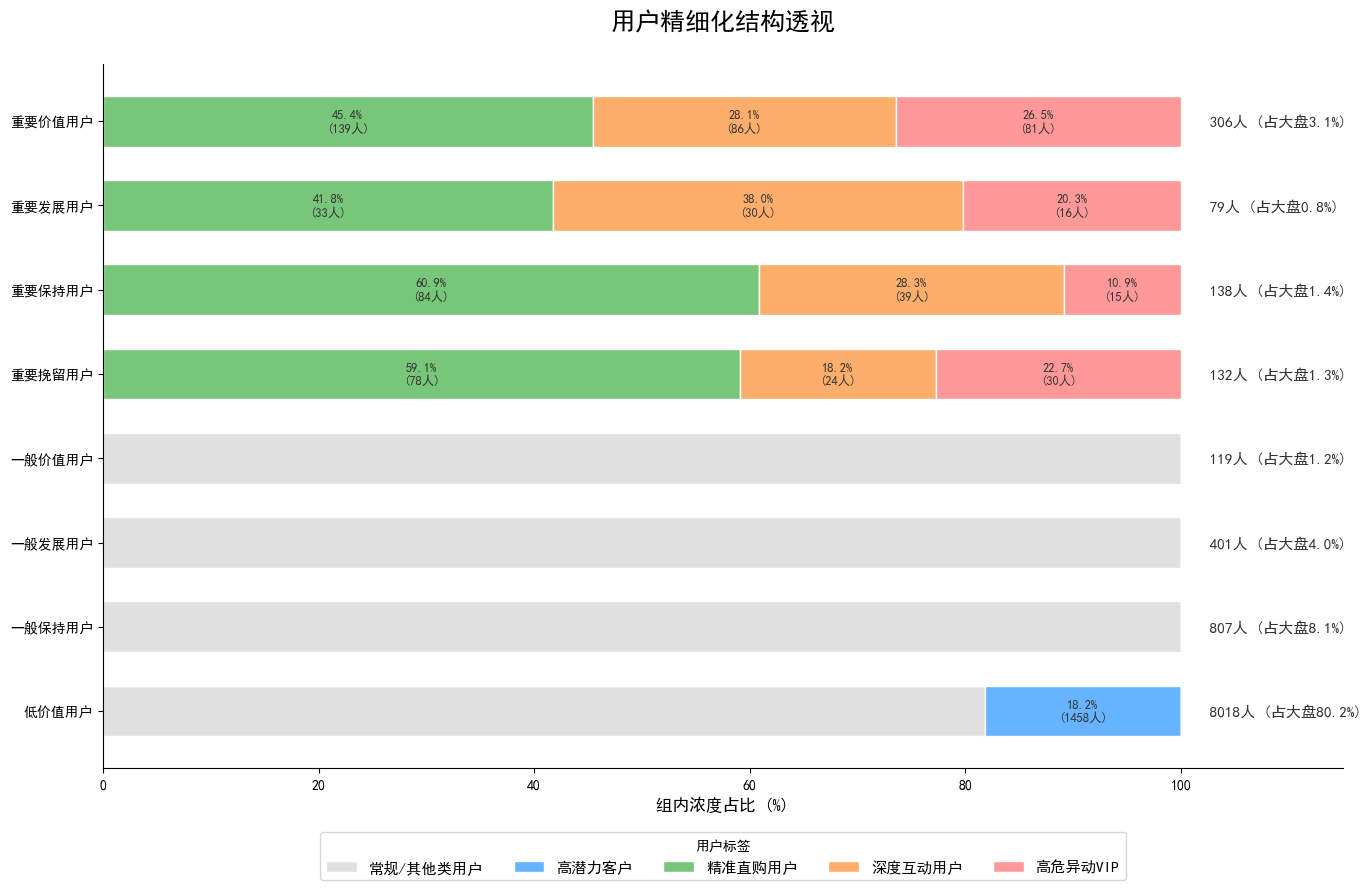

In [10]:
def plot_strategic_segments_matrix_100pct(df):
    """
    绘制 100% 组内归一化横向堆叠条形图，透视用户精细化结构。

    消除底层庞大常规用户群绝对数量造成的"视觉坍塌"，将横轴统一为"组内浓度占比"，
    聚焦展示四大重点战略人群在各 RFM 阶层内部的真实分布占比。

    Parameters:
    -----------
    df : pandas.DataFrame
        包含最终分层结果 'Base_Segment' 和 'User_Segment' 的数据框。

    Returns:
    --------
    None
        直接在前端输出交互式或静态图表。
    """

    # 1. 标签归纳映射
    def categorize_for_plot(label):
        if '高危异动VIP' in label:
            return '高危异动VIP'
        elif '深度互动用户' in label:
            return '深度互动用户'
        elif '精准直购用户' in label:
            return '精准直购用户'
        elif '高潜力' in label:
            return '高潜力客户'
        else:
            return '常规/其他类用户'

    df['Plot_Category'] = df['User_Segment'].apply(categorize_for_plot)

    # 2. 创建交叉表
    plot_data = pd.crosstab(df['Base_Segment'], df['Plot_Category'])

    # 预定顺序
    plot_cols = ['常规/其他类用户', '高潜力客户', '精准直购用户', '深度互动用户', '高危异动VIP']
    for col in plot_cols:
        if col not in plot_data.columns:
            plot_data[col] = 0

    plot_data = plot_data[plot_cols]

    # RFM 顺序重排
    rfm_order = [
        "重要价值用户", "重要发展用户", "重要保持用户", "重要挽留用户",
        "一般价值用户", "一般发展用户", "一般保持用户", "低价值用户"
    ]
    plot_data = plot_data.reindex(rfm_order[::-1]).fillna(0)
    total_users = len(df)

    # ================= 核心修改区域 =================
    # 提前算出每一层（每一行）的总人数
    row_totals = plot_data.sum(axis=1)

    fig, ax = plt.subplots(figsize=(14, 9))

    colors = {
        '常规/其他类用户': '#e0e0e0',
        '高潜力客户': '#66b3ff',
        '精准直购用户': '#78c679',
        '深度互动用户': '#fdae6b',
        '高危异动VIP': '#ff9999'
    }

    # 左侧起始位置（现在它是按百分比累加的，从 0.0 开始）
    left_pos = pd.Series([0.0] * len(plot_data), index=plot_data.index)

    for category in plot_cols:
        values = plot_data[category]  # 这是绝对人数
        # 计算该类别在这一行中的百分比占比 (0-100)
        pct_values = (values / row_totals) * 100

        # 画图时使用百分比作为长度 (pct_values)
        ax.barh(plot_data.index, pct_values, left=left_pos,
                label=category, color=colors[category], edgecolor='white', height=0.6)

        # 内部文字标签逻辑
        if category != '常规/其他类用户':
            for i, val in enumerate(values):
                if val > 0:
                    pct = pct_values.iloc[i]  # 直接取刚才算好的百分比
                    # X轴文字位置也必须基于百分比来定位
                    x_pos = left_pos.iloc[i] + pct / 2

                    if pct > 1.5:
                        ax.text(x_pos, i, f'{pct:.1f}%\n({int(val)}人)',
                                ha='center', va='center', color='#333333', fontsize=9, fontweight='bold')

        # 累加左侧位置（用百分比累加）
        left_pos += pct_values

    # 4. 最右侧文字：所有柱子现在都到100%就齐平了，所以固定在102%的位置写总人数
    for i, (idx, row) in enumerate(plot_data.iterrows()):
        total_bar = row.sum()
        pct_total = (total_bar / total_users) * 100
        # 固定在 x=102 的位置打上标签
        ax.text(102, i, f' {int(total_bar)}人 (占大盘{pct_total:.1f}%)',
                ha='left', va='center', color='#333333', fontsize=11, fontweight='bold')

    # ================================================

    # 5. 图表装饰与美化
    # X轴的范围固定为 0 到 115（多留15%的空间给最右侧的文字）
    ax.set_xlim(0, 115)

    plt.title('用户精细化结构透视', fontsize=18, pad=25, fontweight='bold')
    # 更改X轴的单位
    plt.xlabel('组内浓度占比 (%)', fontsize=12)
    plt.ylabel('', fontsize=12)

    plt.legend(title='用户标签', bbox_to_anchor=(0.5, -0.08), loc='upper center', ncol=5, fontsize=11)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

# 调用全新的 100% 堆叠图函数
plot_strategic_segments_matrix_100pct(final_df)

# 模型验证

## 时间回溯验证（11月）

In [11]:
# ═══════════════════════════════════════════════════
# 时间回溯验证
# ═══════════════════════════════════════════════════

from scipy.stats import chi2_contingency, chi2, binomtest, wilcoxon

# ==================================================
# 实验 1：高潜力用户 vs 普通低价值用户（11月转化对比）
# ==================================================
print("=" * 58)
print("【实验 1】高潜力用户 ⇢ 11月转化率显著性检验")
print("=" * 58)

# ── 圈定人群 ──
target_potential_ids = final_df[
    final_df['User_Segment'] == '高潜力用户'
]['user_id'].unique()

low_value_base_ids = final_df[
    final_df['Base_Segment'].isin(['低价值用户', '一般发展用户'])
]['user_id'].unique()
control_low_value_ids = final_df[
    final_df['user_id'].isin(low_value_base_ids) &
    (final_df['User_Segment'] != '高潜力用户')
]['user_id'].unique()

print(f"实验组（高潜力用户）: {len(target_potential_ids)} 人")
print(f"对照组（普通低价值）: {len(control_low_value_ids)} 人\n")

# ── 计算 11 月购买人数 ──
exp_buyers = df_nov[df_nov['user_id'].isin(target_potential_ids) &
                    (df_nov['event_type'] == 'purchase')]['user_id'].nunique()
ctrl_buyers = df_nov[df_nov['user_id'].isin(control_low_value_ids) &
                     (df_nov['event_type'] == 'purchase')]['user_id'].nunique()

exp_no = len(target_potential_ids) - exp_buyers
ctrl_no = len(control_low_value_ids) - ctrl_buyers

exp_cvr = exp_buyers / len(target_potential_ids)
ctrl_cvr = ctrl_buyers / len(control_low_value_ids)

print(f"  实验组转化率: {exp_cvr:.2%}  ({exp_buyers}/{len(target_potential_ids)})")
print(f"  对照组转化率: {ctrl_cvr:.2%}  ({ctrl_buyers}/{len(control_low_value_ids)})")
print(f"  转化率提升: {(exp_cvr/ctrl_cvr - 1)*100:+.1f}%\n")

# ── 卡方检验 ──
ct = [[exp_buyers, exp_no], [ctrl_buyers, ctrl_no]]
chi2_stat, chi2_p, chi2_dof, chi2_expected = chi2_contingency(ct, correction=True)
print(f"📊 卡方检验（Yates 校正）")
print(f"  χ² = {chi2_stat:.4f},  p = {chi2_p:.4f}" if chi2_p >= 0.0001 else f"  χ² = {chi2_stat:.4f},  p = {chi2_p:.2e}")
# 自检
if chi2_p >= 0.0001:
    pass
elif chi2_p > 0:
    print(f"   (实际 p = {chi2_p:.6e}，极显著)")
else:
    print(f"  ⚠️ p = 0.000000 — 差异大到超出浮点精度")
if chi2_p < 0.05:
    print(f"  ✅ p < 0.05 → 两组转化率差异具有统计显著性")
else:
    print(f"  ❌ p >= 0.05 → 差异可能由随机波动导致")
print()

# ==================================================
# 实验 2：高危异动VIP 十月 vs 十一月（转化率+客单价衰退检验）
# ==================================================
print("=" * 58)
print("【实验 2】高危异动VIP ⇢ 10月 vs 11月衰退显著性检验")
print("=" * 58)

target_risk_vip_ids = final_df[
    final_df['User_Segment'].str.contains('高危异动', na=False)
]['user_id'].unique()
n_vip = len(target_risk_vip_ids)

print(f"高危异动VIP 人数: {n_vip}\n")

# 导出兼容：补上其他 VIP 人群的名单变量
target_immersive_vip_ids = final_df[
    final_df['User_Segment'].str.contains('深度互动', na=False)
]['user_id'].unique()
target_efficient_vip_ids = final_df[
    final_df['User_Segment'].str.contains('精准直购', na=False)
]['user_id'].unique()

# ── 10 月数据 ──
vip_oct = final_df[final_df['user_id'].isin(target_risk_vip_ids)].copy()
vip_oct_bought = vip_oct['Purchase_Frequency'] > 0
vip_oct_buyers_n = vip_oct_bought.sum()
vip_oct_cvr = vip_oct_buyers_n / n_vip
vip_oct_arppu = vip_oct.loc[vip_oct_bought, 'Total_Spending'].mean()
print(f"  10月转化率: {vip_oct_cvr:.2%}  ({vip_oct_buyers_n}/{n_vip})")
print(f"  10月客单价(ARPPU): {vip_oct_arppu:.2f} 元")

# ── 11 月数据 ──
vip_nov_purchases = df_nov[
    (df_nov['user_id'].isin(target_risk_vip_ids)) &
    (df_nov['event_type'] == 'purchase')
]
vip_nov_buyers_n = vip_nov_purchases['user_id'].nunique()
vip_nov_revenue = vip_nov_purchases['price'].sum()
vip_nov_cvr = vip_nov_buyers_n / n_vip
vip_nov_arppu = vip_nov_revenue / vip_nov_buyers_n if vip_nov_buyers_n > 0 else 0

print(f"  11月转化率: {vip_nov_cvr:.2%}  ({vip_nov_buyers_n}/{n_vip})")
print(f"  11月客单价(ARPPU): {vip_nov_arppu:.2f} 元")
print()

# ── McNemar 检验：转化率配对变化 ──
# 建立 2×2 表：[Oct:未买/买了] × [Nov:未买/买了]
nov_bought_set = set(vip_nov_purchases['user_id'].unique())
a = b = c = d = 0
for uid in target_risk_vip_ids:
    oct_buy = vip_oct.loc[vip_oct['user_id'] == uid, 'Purchase_Frequency'].values[0] > 0
    nov_buy = uid in nov_bought_set
    if not oct_buy and not nov_buy: a += 1
    if not oct_buy and nov_buy:     b += 1
    if oct_buy and not nov_buy:     c += 1
    if oct_buy and nov_buy:         d += 1

print(f"  McNemar 配对表:")
print(f"                  Nov:未买  Nov:买了")
print(f"  Oct:未买          {a}        {b}")
print(f"  Oct:买了          {c}        {d}")

if b + c > 0:
    # 有连续校正的 McNemar: χ² = (|b-c| - 1)² / (b+c)
    mcnemar_stat = (abs(b - c) - 1) ** 2 / (b + c)
    mcnemar_p = 1 - chi2.cdf(mcnemar_stat, 1)
    print(f"\n  McNemar χ² = {mcnemar_stat:.4f},  p = {mcnemar_p:.4f}" if mcnemar_p >= 0.0001 else f"\n  McNemar χ² = {mcnemar_stat:.4f},  p = {mcnemar_p:.2e}")
    if mcnemar_p < 0.05:
        print(f"  ✅ p < 0.05 → 转化率变化具有统计显著性")
    else:
        print(f"  ❌ p >= 0.05 → 转化率变化不显著")
else:
    print(f"  ⚠️ 对角元为 0，无法进行 McNemar 检验")

# ── Wilcoxon 符号秩检验：户均消费配对变化 ──
vip_oct_spending = vip_oct.set_index('user_id')['Total_Spending']
vip_nov_spending = (
    df_nov[df_nov['user_id'].isin(target_risk_vip_ids)]
    .groupby('user_id')['price'].sum()
)
# 对齐索引
all_spending = pd.DataFrame({
    'oct': vip_oct_spending.reindex(target_risk_vip_ids, fill_value=0),
    'nov': vip_nov_spending.reindex(target_risk_vip_ids, fill_value=0)
})

oct_mean = all_spending['oct'].mean()
nov_mean = all_spending['nov'].mean()
print(f"\n  10月户均消费: {oct_mean:.2f} 元")
print(f"  11月户均消费: {nov_mean:.2f} 元")
print(f"  户均变化: {nov_mean - oct_mean:+.2f} 元")

w_stat, w_p = wilcoxon(all_spending['oct'], all_spending['nov'])
print(f"\n  Wilcoxon W = {w_stat:.1f},  p = {w_p:.4f}" if w_p >= 0.0001 else f"\n  Wilcoxon W = {w_stat:.1f},  p = {w_p:.2e}")
if w_p < 0.05:
    print(f"  ✅ p < 0.05 → 户均消费变化具有统计显著性")
else:
    print(f"  ❌ p >= 0.05 → 户均消费变化不显著")
print()

# ==================================================
# 汇总报告（沿用之前的多人群对比表）
# ==================================================
print("=" * 58)
print("📊 各人群 11 月转化率汇总")
print("=" * 58)

def evaluate_nov_performance(user_list, group_name):
    if len(user_list) == 0:
        return None
    group_nov = df_nov[df_nov['user_id'].isin(user_list)]
    nov_purchases = group_nov[group_nov['event_type'] == 'purchase']
    buyers = nov_purchases['user_id'].nunique()
    cvr = buyers / len(user_list)
    rev = nov_purchases['price'].sum()
    arppu = rev / buyers if buyers > 0 else 0
    return {
        '人群分组': group_name,
        '人数': len(user_list),
        '11月下单': buyers,
        '转化率': f"{cvr:.2%}",
        '11月营收': round(rev, 2),
        'ARPPU': round(arppu, 2)
    }

groups = [
    (target_potential_ids, "实验组-高潜力用户"),
    (control_low_value_ids, "对照组-普通低价值"),
    (target_risk_vip_ids, "高危异动VIP"),
    (final_df[final_df['User_Segment'].str.contains('深度互动', na=False)]['user_id'].unique(), "深度互动用户"),
    (final_df[final_df['User_Segment'].str.contains('精准直购', na=False)]['user_id'].unique(), "精准直购用户"),
]

report = pd.DataFrame([g for g in [evaluate_nov_performance(*g) for g in groups] if g is not None])
display(HTML(report.to_html(index=False)))

【实验 1】高潜力用户 ⇢ 11月转化率显著性检验
实验组（高潜力用户）: 1458 人
对照组（普通低价值）: 6961 人

  实验组转化率: 16.53%  (241/1458)
  对照组转化率: 6.44%  (448/6961)
  转化率提升: +156.8%

📊 卡方检验（Yates 校正）
  χ² = 162.1099,  p = 0.0000
  ✅ p < 0.05 → 两组转化率差异具有统计显著性

【实验 2】高危异动VIP ⇢ 10月 vs 11月衰退显著性检验
高危异动VIP 人数: 142

  10月转化率: 100.00%  (142/142)
  10月客单价(ARPPU): 1415.30 元
  11月转化率: 42.25%  (60/142)
  11月客单价(ARPPU): 1535.01 元

  McNemar 配对表:
                  Nov:未买  Nov:买了
  Oct:未买          0        0
  Oct:买了          82        60

  McNemar χ² = 80.0122,  p = 0.0000
  ✅ p < 0.05 → 转化率变化具有统计显著性

  10月户均消费: 1415.30 元
  11月户均消费: 38034.72 元
  户均变化: +36619.42 元

  Wilcoxon W = 317.0,  p = 0.0000
  ✅ p < 0.05 → 户均消费变化具有统计显著性

📊 各人群 11 月转化率汇总


人群分组,人数,11月下单,转化率,11月营收,ARPPU
实验组-高潜力用户,1458,241,16.53%,161014.85,668.11
对照组-普通低价值,6961,448,6.44%,292334.78,652.53
高危异动VIP,142,60,42.25%,92100.39,1535.01
深度互动用户,179,88,49.16%,362439.44,4118.63
精准直购用户,334,148,44.31%,273842.10,1850.28


## 结果持久化

In [12]:
export_data = []
for uid in target_potential_ids:
    export_data.append({'user_id': uid, '追踪分组': '实验组-高潜力用户'})
for uid in control_low_value_ids:
    export_data.append({'user_id': uid, '追踪分组': '对照组-普通低价值'})
for uid in target_risk_vip_ids:
    export_data.append({'user_id': uid, '追踪分组': '高危异动VIP'})
for uid in target_immersive_vip_ids:
    export_data.append({'user_id': uid, '追踪分组': '深度互动用户'})
for uid in target_efficient_vip_ids:
    export_data.append({'user_id': uid, '追踪分组': '精准直购用户'})

df_tracked_users = pd.DataFrame(export_data)
df_tracked_users.to_csv('tracked_users_list_Nov.csv', index=False, encoding='utf-8-sig')
print(f"共计 {len(df_tracked_users)} 名目标用户的名单已保存至: tracked_users_list_Nov.csv")

共计 9074 名目标用户的名单已保存至: tracked_users_list_Nov.csv


## 模型收益

In [13]:
def calculate_time_series_growth(df_oct_features, df_nov_raw, target_segment="高潜力"):
    target_df = df_oct_features[
        df_oct_features['User_Segment'].str.contains(target_segment, na=False)
    ]
    target_ids = target_df['user_id'].unique()
    num_potential = len(target_ids)
    total_users = len(df_oct_features)
    potential_ratio = num_potential / total_users if total_users > 0 else 0

    if num_potential == 0:
        print("未找到目标人群，请检查标签匹配逻辑。")
        return

    oct_revenue = target_df['Total_Spending'].sum()
    global_oct_revenue = df_oct_features['Total_Spending'].sum()

    nov_group_data = df_nov_raw[df_nov_raw['user_id'].isin(target_ids)]
    nov_purchases = nov_group_data[nov_group_data['event_type'] == 'purchase']
    nov_buyers = nov_purchases['user_id'].nunique()
    nov_revenue = nov_purchases['price'].sum()

    actual_cvr = nov_buyers / num_potential if num_potential > 0 else 0
    actual_growth = nov_revenue - oct_revenue
    arppu_nov = nov_revenue / nov_buyers if nov_buyers > 0 else 0

    simulated_cvr = 0.2
    simulated_buyers = int(num_potential * simulated_cvr)
    simulated_nov_revenue = simulated_buyers * arppu_nov
    simulated_growth = simulated_nov_revenue - oct_revenue

    print("=" * 55)
    print(f"【{target_segment}】跨月真实增长与营销潜力测算")
    print("=" * 55)
    print(f"目标人群基数: {num_potential} 人 (占 {potential_ratio:.2%})")
    print()
    print(f"【自然跨月 (10月→11月)】")
    print(f"  10月消费: {oct_revenue:,.2f} 元")
    print(f"  11月消费: {nov_revenue:,.2f} 元")
    print(f"  实际转化率: {actual_cvr:.2%} ({nov_buyers}人)")
    print(f"  跨月净增长: {actual_growth:,.2f} 元")
    print()
    print(f"【模拟干预 (目标转化率 {simulated_cvr:.0%})】")
    print(f"  预期买家: {simulated_buyers} 人")
    print(f"  预期11月消费: {simulated_nov_revenue:,.2f} 元")
    print(f"  预期净增长: {simulated_growth:,.2f} 元")
    print("-" * 55)
    extra_uplift = simulated_growth - actual_growth
    print(f"  纯额外增量: {extra_uplift:,.2f} 元")
    if oct_revenue > 0:
        print(f"  额外拉动历史业绩: {extra_uplift/oct_revenue:.2%}")
    if global_oct_revenue > 0:
        print(f"  拉动大盘总业绩: {extra_uplift/global_oct_revenue:.2%}")

calculate_time_series_growth(final_df, df_nov, target_segment="高潜力")

【高潜力】跨月真实增长与营销潜力测算
目标人群基数: 1458 人 (占 14.58%)

【自然跨月 (10月→11月)】
  10月消费: 0.00 元
  11月消费: 161,014.85 元
  实际转化率: 16.53% (241人)
  跨月净增长: 161,014.85 元

【模拟干预 (目标转化率 20%)】
  预期买家: 291 人
  预期11月消费: 194,420.42 元
  预期净增长: 194,420.42 元
-------------------------------------------------------
  纯额外增量: 33,405.57 元
  拉动大盘总业绩: 1.64%
